In [ ]:
!pip install datasets[audio] soundfile librosa torchcodec gradio
from datasets import load_dataset
minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
print(minds)


Dataset({
    features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
    num_rows: 654
})


In [ ]:
example = minds[0]
example


{'path': 'en-AU~PAY_BILL/response_4.wav',
 'audio': <datasets.features._torchcodec.AudioDecoder at 0x7beda6c744d0>,
 'transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'english_transcription': 'I would like to pay my electricity bill using my card can you please assist',
 'intent_class': 13,
 'lang_id': 2}

In [ ]:
example = minds[0]

id2label = minds.features["intent_class"].int2str
print(f"这段音频的真实意图是: {id2label(example['intent_class'])}")

# 数据清洗：移除不需要的特征列（特征降维，减轻后续处理负担）
columns_to_remove = ["lang_id", "english_transcription"]
minds = minds.remove_columns(columns_to_remove)

print("\n清洗后的数据集结构：")
print(minds)

这段音频的真实意图是: pay_bill

清洗后的数据集结构：
Dataset({
    features: ['path', 'audio', 'transcription', 'intent_class'],
    num_rows: 654
})


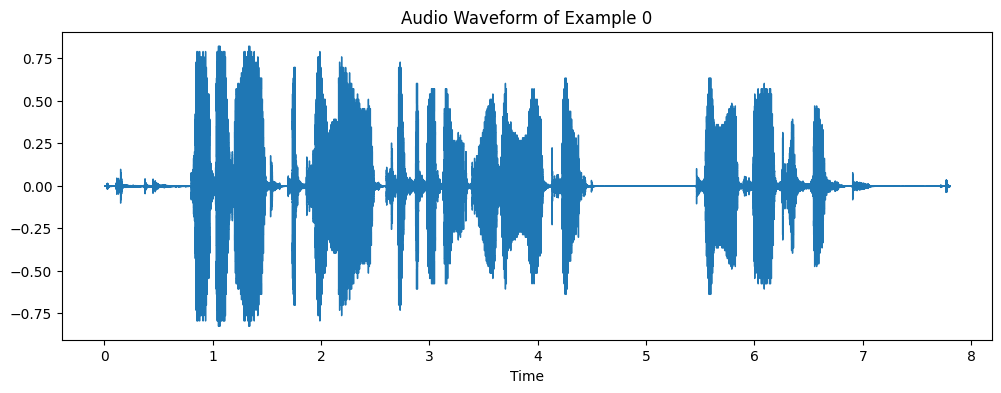

/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))
/usr/local/lib/python3.12/dist-packages/gradio/processing_utils.py:688: UserWarning: Trying to convert audio automatically from float32 to 16-bit int format.
  warnings.warn(warning.format(data.dtype))


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://fcb70acbbea9a1be66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://fcb70acbbea9a1be66.gradio.live


In [ ]:
import gradio as gr
import librosa
import matplotlib.pyplot as plt
import librosa.display

# --- 视觉部分：画出音频波形图 ---
array = example["audio"]["array"]
sampling_rate = example["audio"]["sampling_rate"]

plt.figure(figsize=(12, 4))
plt.title("Audio Waveform of Example 0")
librosa.display.waveshow(array, sr=sampling_rate)
plt.show()

# --- 听觉部分：构建一个随机播放的迷你播放器 ---
def generate_audio():
    # 随机打乱数据集，取第一条
    random_example = minds.shuffle()[0]
    audio = random_example["audio"]
    return (
        audio["sampling_rate"],
        audio["array"],
    ), id2label(random_example["intent_class"])

with gr.Blocks() as demo:
    gr.Markdown("MINDS-14 随机音频")
    with gr.Column():
        for _ in range(4):
            audio_data, label = generate_audio()
            gr.Audio(audio_data, label=label)

# 启动播放器
demo.launch(debug=True)

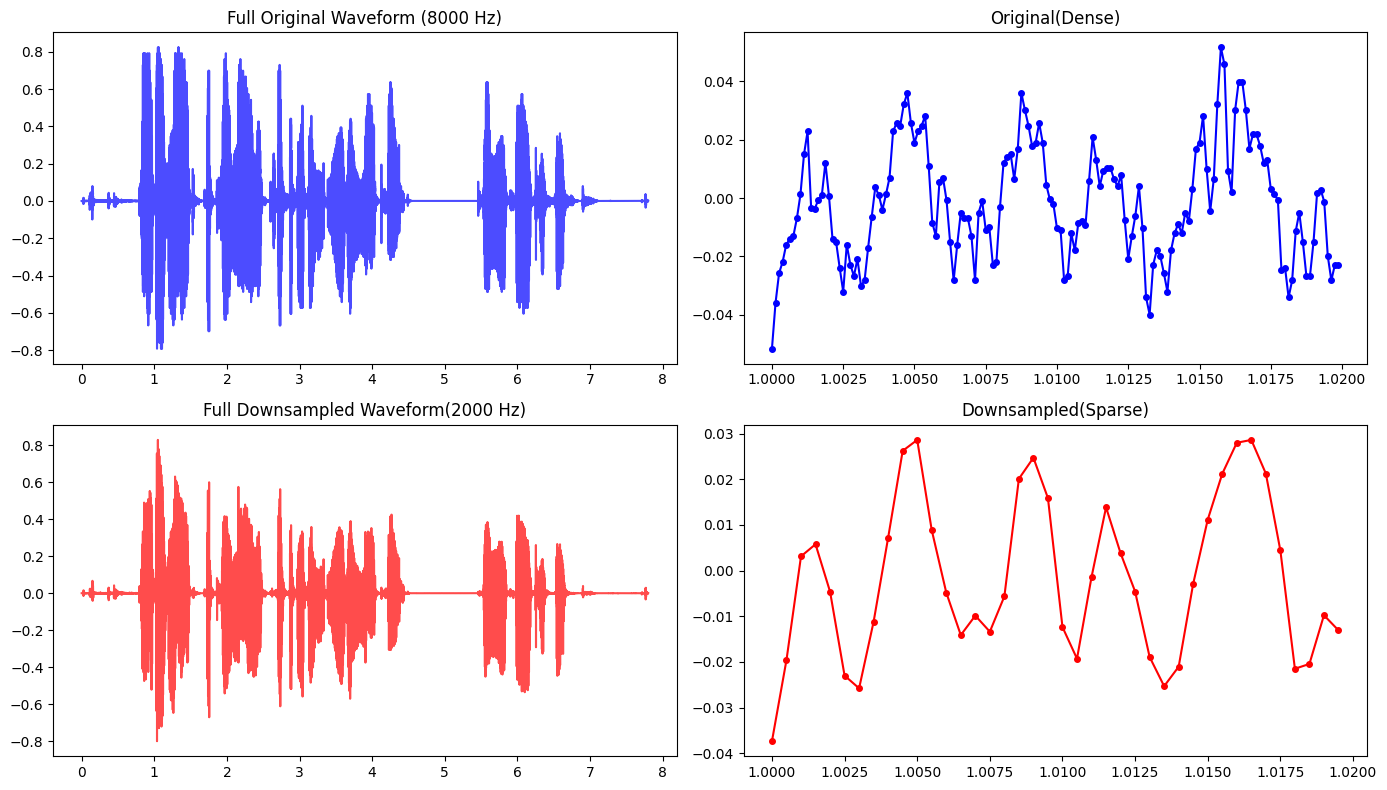

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. 提取原始音频 (8000 Hz)
example = minds[0]
if isinstance(example["audio"], dict) and "array" in example["audio"]:
    array_orig = np.array(example["audio"]["array"])
    sr_orig = example["audio"]["sampling_rate"]
else:
    # 1. 提取张量并转为一维的 numpy 数组
    samples = example["audio"].get_all_samples()
    array_orig = samples.data.squeeze().numpy()

    # 2. 终极兼容版获取采样率
    if hasattr(example["audio"], "sample_rate"):
        sr_orig = example["audio"].sample_rate
    elif hasattr(samples, "sample_rate"):
        sr_orig = samples.sample_rate
    else:
        sr_orig = 8000

# 2. 我们进行夸张的下采样：把 8000 Hz 降到 2000 Hz (方便肉眼观察)
sr_down = 2000
# 使用 librosa 的 resample 函数（它内置了防混叠的低通滤波器！）
array_down = librosa.resample(y=array_orig, orig_sr=sr_orig, target_sr=sr_down)

# 3. 画图对比
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# --- 左侧：宏观波形对比 ---
time_orig = np.arange(len(array_orig)) / sr_orig
axs[0, 0].plot(time_orig, array_orig, color='blue', alpha=0.7)
axs[0, 0].set_title(f"Full Original Waveform ({sr_orig} Hz)")

time_down = np.arange(len(array_down)) / sr_down
axs[1, 0].plot(time_down, array_down, color='red', alpha=0.7)
axs[1, 0].set_title(f"Full Downsampled Waveform({sr_down} Hz)")

# --- 右侧：微观放大镜 (截取 1.0秒 到 1.02秒) ---
zoom_start, zoom_end = 1.0, 1.02
start_idx_orig = int(zoom_start * sr_orig)
end_idx_orig = int(zoom_end * sr_orig)
axs[0, 1].plot(time_orig[start_idx_orig:end_idx_orig], array_orig[start_idx_orig:end_idx_orig], 'bo-', markersize=4)
axs[0, 1].set_title("Original(Dense)")

start_idx_down = int(zoom_start * sr_down)
end_idx_down = int(zoom_end * sr_down)
axs[1, 1].plot(time_down[start_idx_down:end_idx_down], array_down[start_idx_down:end_idx_down], 'ro-', markersize=4)
axs[1, 1].set_title("Downsampled(Sparse)")

plt.tight_layout()
plt.show()